In [219]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, root_mean_squared_error
import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Preprocessing

In [190]:
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

In [ ]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Gradient Descent and Linear Regression Implementation

In [205]:
def gradient_descent(X,Y,params,lr = 0.05,iter=1000):
  X = (X-X_mean)/X_std
  X = np.c_[np.ones((X.shape[0], 1)), X]
  m = X.shape[0]
  cost_history = []
  for i in range(iter):
    pred = X@params
    error = pred-Y
    grad = (X.T@(error))/m
    cost = np.sum(error**2)/(2*m)
    cost_history.append(cost)
    params = params - lr*(grad)
  return params,cost_history


In [214]:
def predict(W,X):
  X = (X-X_mean)/X_std
  X = np.c_[np.ones((X.shape[0], 1)), X]
  pred = X@W
  return pred

In [206]:
W,costs = gradient_descent(X_train,y_train,np.zeros((X.shape[1]+1,1)),lr=0.05,iter=1000)

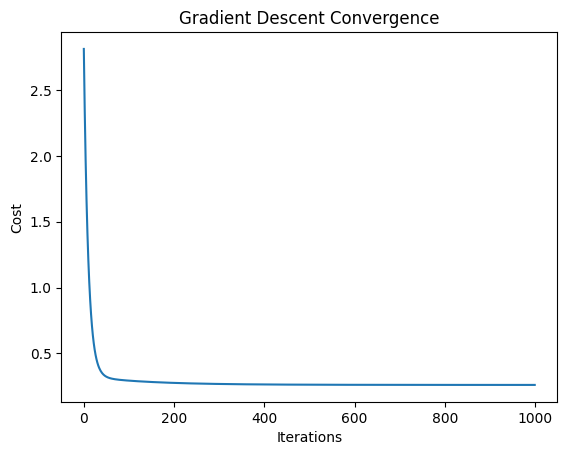

In [207]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()


## Error metrics/ Evaluation Metrics
1. MSE
2. RMS
3. MAV

In [210]:
def MSE(y_true,y_pred):
  return np.mean((y_true-y_pred)**2)

In [211]:
def RMS(y_true,y_pred):
  return np.sqrt(np.mean((y_true-y_pred)**2))

In [212]:
def MAV(y_true,y_pred):
  return np.mean(np.abs(y_true-y_pred))

In [216]:
def r_squared(y_true, y_pred):
    y_mean = np.mean(y_true)
    sst = np.sum((y_true - y_mean) ** 2)
    ssr = np.sum((y_true - y_pred) ** 2)
    if sst == 0:
        return 1.0 if ssr == 0 else float("inf")
    r_squared = 1 - (ssr / sst)
    return r_squared

In [217]:
print(MSE(y_train,predict(W,X_train)))
print(RMS(y_train,predict(W,X_train)))
print(MAV(y_train,predict(W,X_train)))
print(r_squared(y_train,predict(W,X_train)))

0.5180613512498449
0.7197647888371901
0.5282399338218535
0.6124552699311565


## Training with sklearn.

In [218]:
model  = LinearRegression().fit(X_train,y_train)

In [220]:
y_pred = model.predict(X_test)

In [221]:
print(mean_squared_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.555891598695244
0.7455813830127761
0.5332001304956565
0.5757877060324511


## Comparision

In [ ]:
metrics = ['MSE', 'RMS',"MAE", 'R2']
your_model = [(MSE(y_train,predict(W,X_train))),
(RMS(y_train,predict(W,X_train))),
(MAV(y_train,predict(W,X_train))),
(r_squared(y_train,predict(W,X_train)))
]
sklearn_model = [(mean_squared_error(y_test,y_pred)),
(root_mean_squared_error(y_test,y_pred)),
(mean_absolute_error(y_test,y_pred)),
(r2_score(y_test,y_pred))
]

df = pd.DataFrame({
    'Metric': metrics*2,
    'Value': your_model + sklearn_model,
    'Model': ['My Model']*4 + ['Sklearn']*4
})

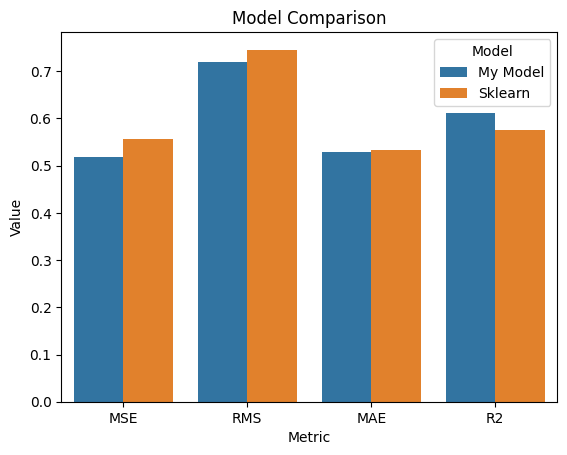

In [225]:
sns.barplot(x='Metric', y='Value', hue='Model', data=df)
plt.title("Model Comparison")
plt.show()

# Conclusions

So my model performs very similar to Sklearn model in metrics on this dataset.